In [1]:

# # CS3807 – Deep Learning Laboratory
# ## Experiment 7: End-to-End Study of Autoencoders, Convolutional Autoencoders,
# ## Denoising Autoencoders and Variational Autoencoders
#
# **This notebook follows Experiment 7 of the laboratory manual and is structured
# similarly to the previous Lab 4 notebook.**
#
# Dataset: MNIST
# Main laboratory execution: full MNIST training and test sets
# Figures: Times New Roman, 600 dpi, EPS format
#
# > Runtime → Change runtime type → GPU (T4) is recommended.
#
# The numerical results in the final tables are produced by running this notebook;
# they are not hard-coded.

# ===== CELL 1: Install Times New Roman (for 600 dpi / EPS figures) =====
!apt-get -qq update > /dev/null 2>&1
!echo "ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true" | debconf-set-selections
!apt-get -qq install -y ttf-mscorefonts-installer > /dev/null 2>&1
!fc-cache -f > /dev/null 2>&1
!fc-list | grep -i "times new roman" || echo "NOT FOUND - fallback font will be used"


/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf: Times New Roman:style=Regular,Normal,obyčejné,Standard,Κανονικά,Normaali,Normál,Normale,Standaard,Normalny,Обычный,Normálne,Navadno,thường,Arrunta
/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Italic.ttf: Times New Roman:style=Italic,cursiva,kurzíva,kursiv,Πλάγια,Kursivoitu,Italique,Dőlt,Corsivo,Cursief,kursywa,Itálico,Курсив,İtalik,Poševno,nghiêng,Etzana
/usr/share/fonts/truetype/msttcorefonts/timesbd.ttf: Times New Roman:style=Bold,Negreta,tučné,fed,Fett,Έντονα,Negrita,Lihavoitu,Gras,Félkövér,Grassetto,Vet,Halvfet,Pogrubiona,Negrito,Полужирный,Fet,Kalın,Krepko,đậm,Lodia
/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold_Italic.ttf: Times New Roman:style=Bold Italic,Negreta cursiva,tučné kurzíva,fed kursiv,Fett Kursiv,Έντονα Πλάγια,Negrita Cursiva,Lihavoitu Kursivoi,Gras Italique,Félkövér dőlt,Grassetto Corsivo,Vet Cursief,Halvfet Kursiv,Pogrubiona kursywa,Negrito Itálico,Полужирный Курсив,Tučná kurzíva

In [2]:

# ===== CELL 1b: Fallback font download =====
!wget -q -O /content/TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
!wget -q -O /content/times.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/times.ttf
!wget -q -O /content/timesbd.ttf https://github.com/FSKiller/Microsoft-Fonts/raw/main/timesbd.ttf


In [3]:
!pip install -q tensorflow scikit-learn scikit-image seaborn matplotlib pandas

In [4]:

# ===== CELL 2: Imports, font configuration, plotting and reproducibility =====
import os
import time
import shutil
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import mnist

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

# Refresh the matplotlib font manager after installing Times New Roman.
for f in os.listdir(matplotlib.get_cachedir()):
    if "fontlist" in f:
        try:
            os.remove(os.path.join(matplotlib.get_cachedir(), f))
        except OSError:
            pass

fm.fontManager = fm.FontManager()

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.dpi"] = 600
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 13

PLOT_DIR = "/content/lab7_outputs"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(fig, name):
    """Save every figure at 600 dpi in EPS format."""
    path = os.path.join(PLOT_DIR, f"{name}.eps")
    fig.savefig(path, format="eps", dpi=600, bbox_inches="tight")
    print(f"Saved: {path}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

N_TRAIN = 60_000
N_TEST = 10_000

BATCH_SIZE = 128
EPOCHS_BASIC = 20
EPOCHS_CAE = 20
EPOCHS_DAE = 20
EPOCHS_VAE = 20
EPOCHS_LATENT = 20

# Main experiment uses the full MNIST train/test sets. Additional exercises use a smaller subset to reduce runtime.
ADD_N_TRAIN = 2_000
ADD_N_TEST = 500
ADD_EPOCHS = 5
ADD_BATCH_SIZE = 128

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
print("Output directory:", PLOT_DIR)


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Output directory: /content/lab7_outputs


In [5]:

# ===== CELL 3: Load MNIST, select the laboratory subset and normalize =====
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

x_train = x_train_full[:N_TRAIN].astype("float32") / 255.0
x_test = x_test_full[:N_TEST].astype("float32") / 255.0

# Add the channel dimension required by convolutional models.
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

y_train = y_train_full[:N_TRAIN].flatten()
y_test = y_test_full[:N_TEST].flatten()

print(f"Training images : {x_train.shape}")
print(f"Training labels : {y_train.shape}")
print(f"Test images     : {x_test.shape}")
print(f"Test labels     : {y_test.shape}")
print(f"Pixel range     : [{x_train.min():.1f}, {x_train.max():.1f}]")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images : (60000, 28, 28, 1)
Training labels : (60000,)
Test images     : (10000, 28, 28, 1)
Test labels     : (10000,)
Pixel range     : [0.0, 1.0]


Saved: /content/lab7_outputs/01_sample_mnist_images.eps


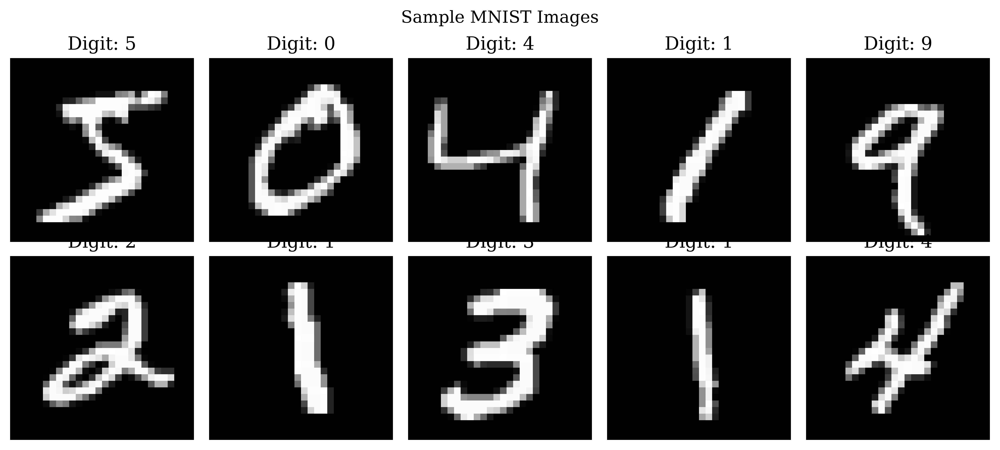

In [6]:

# ===== CELL 4: Display representative MNIST images =====
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].squeeze(), cmap="gray")
    ax.set_title(f"Digit: {y_train[i]}")
    ax.axis("off")

fig.suptitle("Sample MNIST Images")
fig.tight_layout()
save_plot(fig, "01_sample_mnist_images")
plt.show()


In [7]:

# ===== CELL 5: Reconstruction metrics =====
def reconstruction_metrics(x_true, x_pred):
    x_true_flat = x_true.reshape(len(x_true), -1)
    x_pred_flat = x_pred.reshape(len(x_pred), -1)

    mse = np.mean((x_true_flat - x_pred_flat) ** 2)
    mae = np.mean(np.abs(x_true_flat - x_pred_flat))

    ssim_values = [
        ssim(
            x_true[i].squeeze(),
            x_pred[i].squeeze(),
            data_range=1.0
        )
        for i in range(len(x_true))
    ]

    return float(mse), float(mae), float(np.mean(ssim_values)), np.asarray(ssim_values)


def per_image_mse(x_true, x_pred):
    return np.mean(
        (x_true.reshape(len(x_true), -1) - x_pred.reshape(len(x_pred), -1)) ** 2,
        axis=1
    )


def print_metric_row(name, mse, mae, mean_ssim):
    print(f"{name:<25} MSE={mse:.6f} | MAE={mae:.6f} | SSIM={mean_ssim:.6f}")


In [8]:

# ===== CELL 6: Build the fully connected autoencoder =====
fc_autoencoder = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(name="flatten"),
    layers.Dense(128, activation="relu", name="encoder_dense_128"),
    layers.Dense(32, activation="relu", name="encoder_dense_32"),
    layers.Dense(16, activation="relu", name="latent_16"),
    layers.Dense(32, activation="relu", name="decoder_dense_32"),
    layers.Dense(128, activation="relu", name="decoder_dense_128"),
    layers.Dense(784, activation="sigmoid", name="reconstruction"),
    layers.Reshape((28, 28, 1), name="output")
], name="Fully_Connected_Autoencoder")

fc_autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

fc_autoencoder.summary()


Model: "Fully_Connected_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_128 (Dense)       │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_32 (Dense)        │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_16 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_32 (Dense)        │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_128 (Dense)       │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Reshape)                │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:

# ===== CELL 7: Train the fully connected autoencoder =====
t0 = time.time()

history_fc = fc_autoencoder.fit(
    x_train, x_train,
    validation_data=(x_test, x_test),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_BASIC,
    verbose=1
)

fc_train_time = time.time() - t0

fc_recon = fc_autoencoder.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

fc_mse, fc_mae, fc_ssim, fc_ssim_values = reconstruction_metrics(x_test, fc_recon)

print(f"Training time: {fc_train_time:.2f} seconds")
print_metric_row("Fully Connected AE", fc_mse, fc_mae, fc_ssim)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.2130 - val_loss: 0.1560
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1446 - val_loss: 0.1339
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1305 - val_loss: 0.1246
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1230 - val_loss: 0.1186
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1180 - val_loss: 0.1143
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1143 - val_loss: 0.1114
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1117 - val_loss: 0.1091
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1096 - val_loss: 0.1073
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1079 - val_loss: 0.1060
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1066 - val_loss: 0.1051
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1055 - val_loss: 0.1043
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

Saved: /content/lab7_outputs/02_fc_original_vs_reconstruction.eps


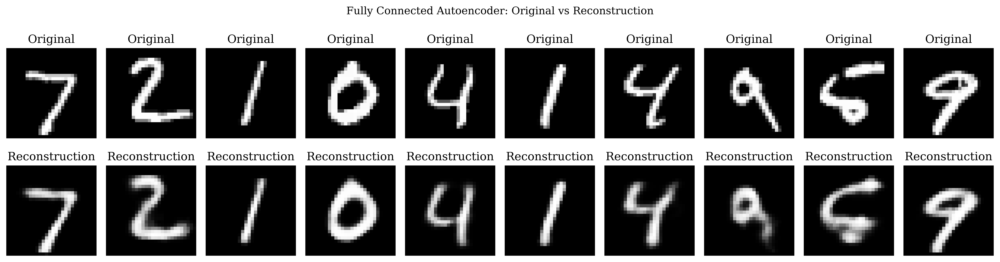

In [10]:

# ===== CELL 8: Plot 1 — Original versus reconstructed images =====
fig, axes = plt.subplots(2, 10, figsize=(16, 4.5))

for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(fc_recon[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Reconstruction")
    axes[1, i].axis("off")

fig.suptitle("Fully Connected Autoencoder: Original vs Reconstruction")
fig.tight_layout()
save_plot(fig, "02_fc_original_vs_reconstruction")
plt.show()


Saved: /content/lab7_outputs/03_fc_training_validation_loss.eps


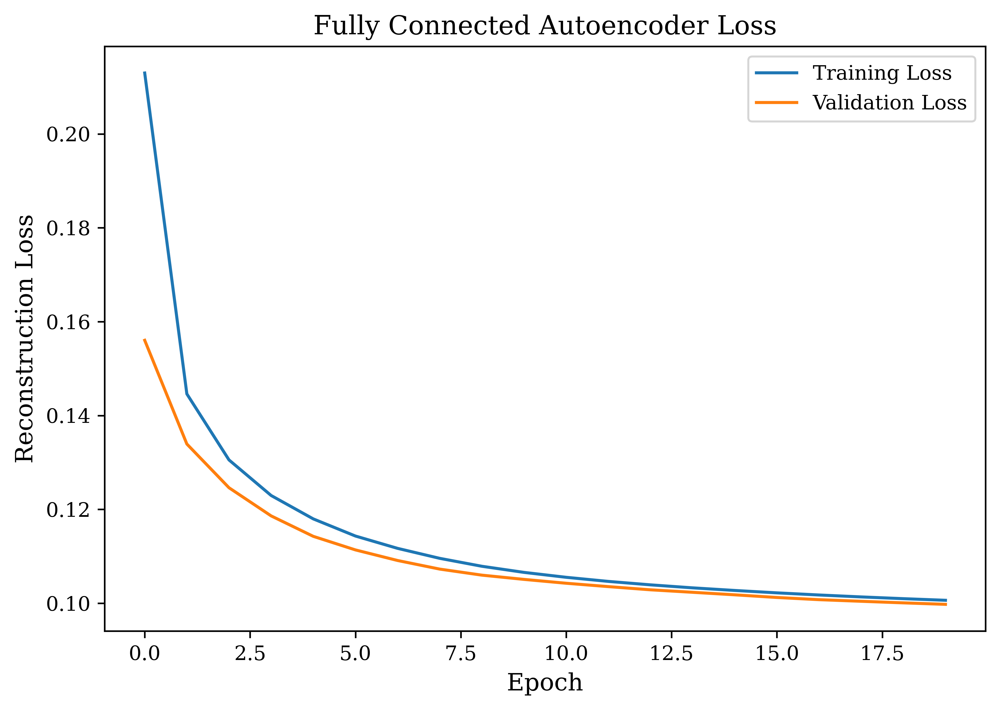

In [11]:

# ===== CELL 9: Plot 2 — Training and validation reconstruction loss =====
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history_fc.history["loss"], label="Training Loss")
ax.plot(history_fc.history["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction Loss")
ax.set_title("Fully Connected Autoencoder Loss")
ax.legend()
fig.tight_layout()
save_plot(fig, "03_fc_training_validation_loss")
plt.show()


In [12]:

# ===== CELL 10: Build the convolutional autoencoder =====
def build_cae(name="Convolutional_Autoencoder"):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2, padding="same"),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2, padding="same"),
        layers.Conv2D(64, 3, activation="relu", padding="same", name="latent_feature_map"),
        layers.UpSampling2D(2),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.UpSampling2D(2),
        layers.Conv2D(1, 3, activation="sigmoid", padding="same")
    ], name=name)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )
    return model

cae = build_cae()
cae.summary()


Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_feature_map (Conv2D)     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:

# ===== CELL 11: Train the convolutional autoencoder =====
t0 = time.time()

history_cae = cae.fit(
    x_train, x_train,
    validation_data=(x_test, x_test),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_CAE,
    verbose=1
)

cae_train_time = time.time() - t0
cae_recon = cae.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

cae_mse, cae_mae, cae_ssim, cae_ssim_values = reconstruction_metrics(x_test, cae_recon)

print(f"Training time: {cae_train_time:.2f} seconds")
print_metric_row("Convolutional AE", cae_mse, cae_mae, cae_ssim)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.1067 - val_loss: 0.0741
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0722 - val_loss: 0.0698
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0696 - val_loss: 0.0684
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0682 - val_loss: 0.0671
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0672 - val_loss: 0.0665
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0665 - val_loss: 0.0659
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0660 - val_loss: 0.0654
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0656 - val_loss: 0.0649
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0652 - val_loss: 0.0646
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0650 - val_loss: 0.0644
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0647 - val_loss: 0.0641
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/st

Saved: /content/lab7_outputs/04_fc_vs_cae_reconstruction.eps


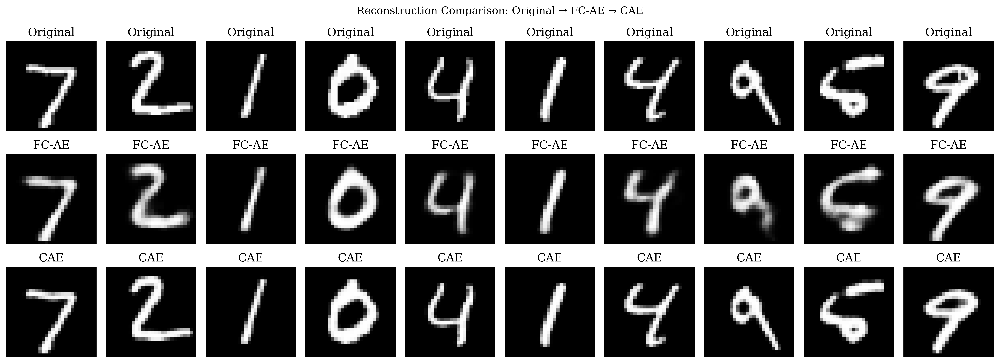

In [14]:

# ===== CELL 12: Plot 3 — Original vs FC-AE vs CAE =====
fig, axes = plt.subplots(3, 10, figsize=(16, 6))

for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(fc_recon[i].squeeze(), cmap="gray")
    axes[1, i].set_title("FC-AE")
    axes[1, i].axis("off")

    axes[2, i].imshow(cae_recon[i].squeeze(), cmap="gray")
    axes[2, i].set_title("CAE")
    axes[2, i].axis("off")

fig.suptitle("Reconstruction Comparison: Original → FC-AE → CAE")
fig.tight_layout()
save_plot(fig, "04_fc_vs_cae_reconstruction")
plt.show()


In [15]:

# ===== CELL 13: Noise generation functions =====
def add_gaussian_noise(images, sigma=0.2, seed=SEED):
    rng = np.random.RandomState(seed)
    noisy = images + rng.normal(0.0, sigma, size=images.shape).astype("float32")
    return np.clip(noisy, 0.0, 1.0).astype("float32")


def add_salt_pepper_noise(images, p=0.1, seed=SEED):
    rng = np.random.RandomState(seed)
    noisy = images.copy()

    random_values = rng.random(images.shape[:3])
    salt_mask = random_values < (p / 2)
    pepper_mask = (random_values >= (p / 2)) & (random_values < p)

    noisy[salt_mask] = 1.0
    noisy[pepper_mask] = 0.0

    return noisy.astype("float32")


# Main training corruption: a controlled 50/50 mixture.
gaussian_train = add_gaussian_noise(x_train, sigma=0.2, seed=SEED)
sp_train = add_salt_pepper_noise(x_train, p=0.1, seed=SEED + 1)

rng = np.random.RandomState(SEED + 2)
mix_mask = rng.rand(len(x_train)) < 0.5

x_denoise_train = gaussian_train.copy()
x_denoise_train[~mix_mask] = sp_train[~mix_mask]

# Evaluation corruption levels required by the manual.
gaussian_levels = [0.1, 0.2, 0.3]
sp_levels = [0.05, 0.10, 0.20]

gaussian_test_sets = {
    sigma: add_gaussian_noise(x_test, sigma=sigma, seed=100 + int(sigma * 100))
    for sigma in gaussian_levels
}

sp_test_sets = {
    p: add_salt_pepper_noise(x_test, p=p, seed=200 + int(p * 100))
    for p in sp_levels
}

print("Gaussian training noise: sigma = 0.2")
print("Salt-and-pepper training noise: p = 0.1")


Gaussian training noise: sigma = 0.2
Salt-and-pepper training noise: p = 0.1


In [16]:

# ===== CELL 14: Build and train the denoising convolutional autoencoder =====
dae = build_cae(name="Denoising_Convolutional_Autoencoder")

t0 = time.time()

history_dae = dae.fit(
    x_denoise_train, x_train,
    validation_data=(gaussian_test_sets[0.2], x_test),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_DAE,
    verbose=1
)

dae_train_time = time.time() - t0

dae_recon = dae.predict(gaussian_test_sets[0.2], batch_size=BATCH_SIZE, verbose=0)

dae_mse, dae_mae, dae_ssim, dae_ssim_values = reconstruction_metrics(
    x_test, dae_recon
)

print(f"Training time: {dae_train_time:.2f} seconds")
print_metric_row("Denoising CAE", dae_mse, dae_mae, dae_ssim)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1200 - val_loss: 0.0817
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0814 - val_loss: 0.0775
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0780 - val_loss: 0.0753
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0764 - val_loss: 0.0742
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0754 - val_loss: 0.0735
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0746 - val_loss: 0.0730
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0740 - val_loss: 0.0726
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0736 - val_loss: 0.0723
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0732 - val_loss: 0.0721
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0728 - val_loss: 0.0719
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0725 - val_loss: 0.0718
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/ste

Saved: /content/lab7_outputs/05_clean_noisy_denoised.eps


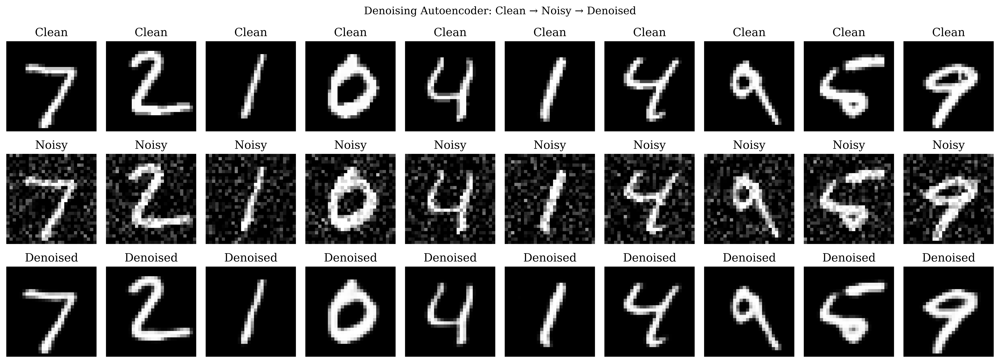

In [17]:

# ===== CELL 15: Plot 4 — Clean vs Noisy vs Denoised =====
fig, axes = plt.subplots(3, 10, figsize=(16, 6))

for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap="gray")
    axes[0, i].set_title("Clean")
    axes[0, i].axis("off")

    axes[1, i].imshow(gaussian_test_sets[0.2][i].squeeze(), cmap="gray")
    axes[1, i].set_title("Noisy")
    axes[1, i].axis("off")

    axes[2, i].imshow(dae_recon[i].squeeze(), cmap="gray")
    axes[2, i].set_title("Denoised")
    axes[2, i].axis("off")

fig.suptitle("Denoising Autoencoder: Clean → Noisy → Denoised")
fig.tight_layout()
save_plot(fig, "05_clean_noisy_denoised")
plt.show()


,Noise Level (sigma),MSE,MAE,SSIM
0,0.1,0.002175,0.014063,0.973820
1,0.2,0.003320,0.017802,0.958926
2,0.3,0.005766,0.025724,0.891524


Saved: /content/lab7_outputs/06_gaussian_noise_vs_mse.eps


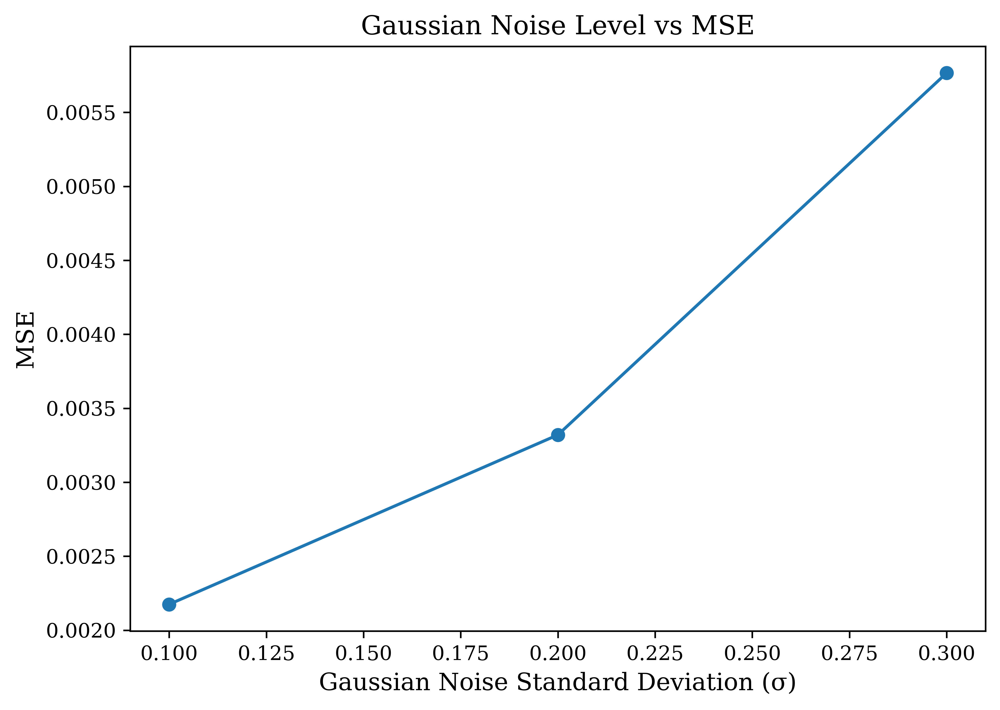

Saved: /content/lab7_outputs/06_gaussian_noise_vs_mae.eps


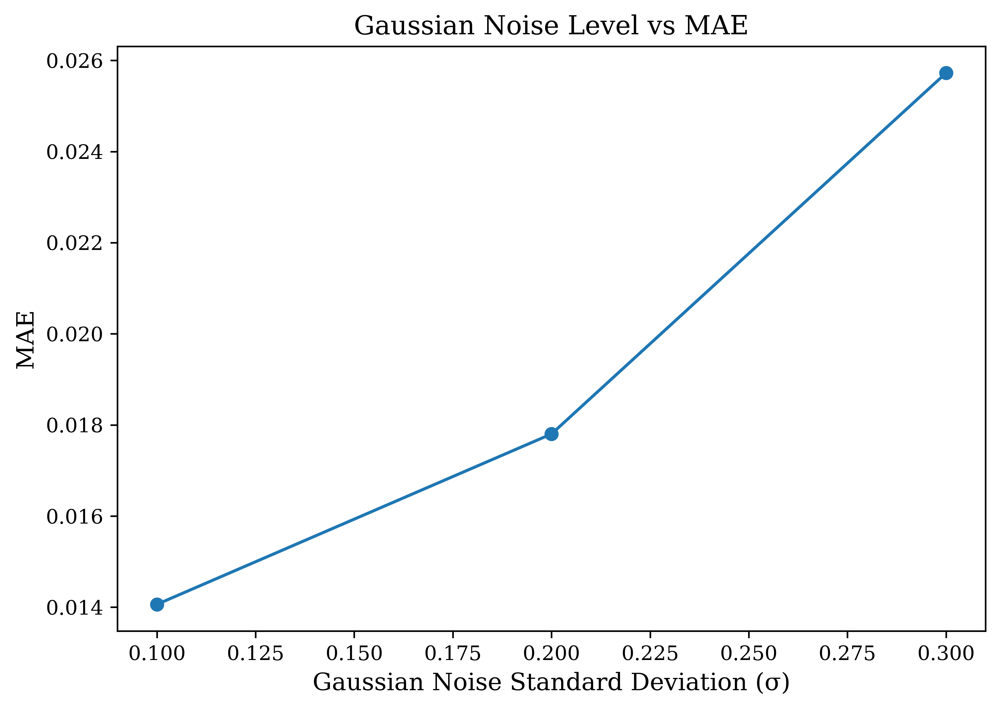

Saved: /content/lab7_outputs/06_gaussian_noise_vs_ssim.eps


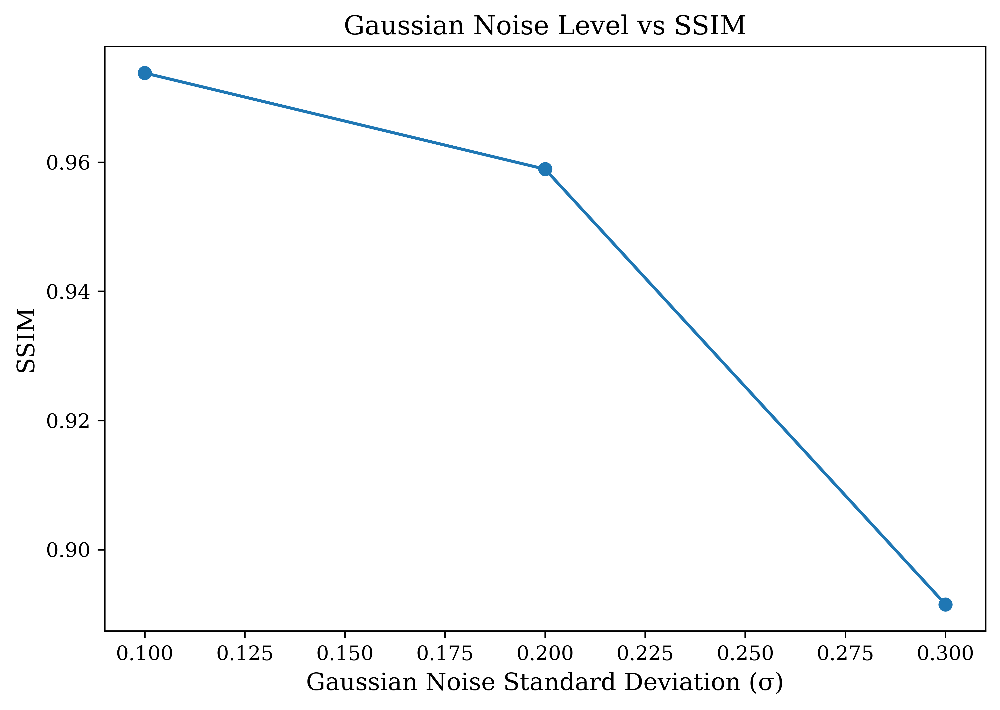

In [18]:

# ===== CELL 16: Plot 5 — Gaussian noise level vs MSE / MAE / SSIM =====
gaussian_metric_rows = []

for sigma, noisy_images in gaussian_test_sets.items():
    denoised = dae.predict(noisy_images, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, mean_ssim, _ = reconstruction_metrics(x_test, denoised)
    gaussian_metric_rows.append([sigma, mse, mae, mean_ssim])

gaussian_metrics_df = pd.DataFrame(
    gaussian_metric_rows,
    columns=["Noise Level (sigma)", "MSE", "MAE", "SSIM"]
)

display(gaussian_metrics_df)

# Separate figures are used because the three measures have incompatible scales.
for metric in ["MSE", "MAE", "SSIM"]:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        gaussian_metrics_df["Noise Level (sigma)"],
        gaussian_metrics_df[metric],
        marker="o"
    )
    ax.set_xlabel("Gaussian Noise Standard Deviation (σ)")
    ax.set_ylabel(metric)
    ax.set_title(f"Gaussian Noise Level vs {metric}")
    fig.tight_layout()
    save_plot(fig, f"06_gaussian_noise_vs_{metric.lower()}")
    plt.show()


,Noise Level (p),MSE,MAE,SSIM
0,0.05,0.002458,0.014373,0.971792
1,0.10,0.003333,0.016674,0.961587
2,0.20,0.006209,0.023199,0.928396


Saved: /content/lab7_outputs/06_sp_noise_vs_mse.eps


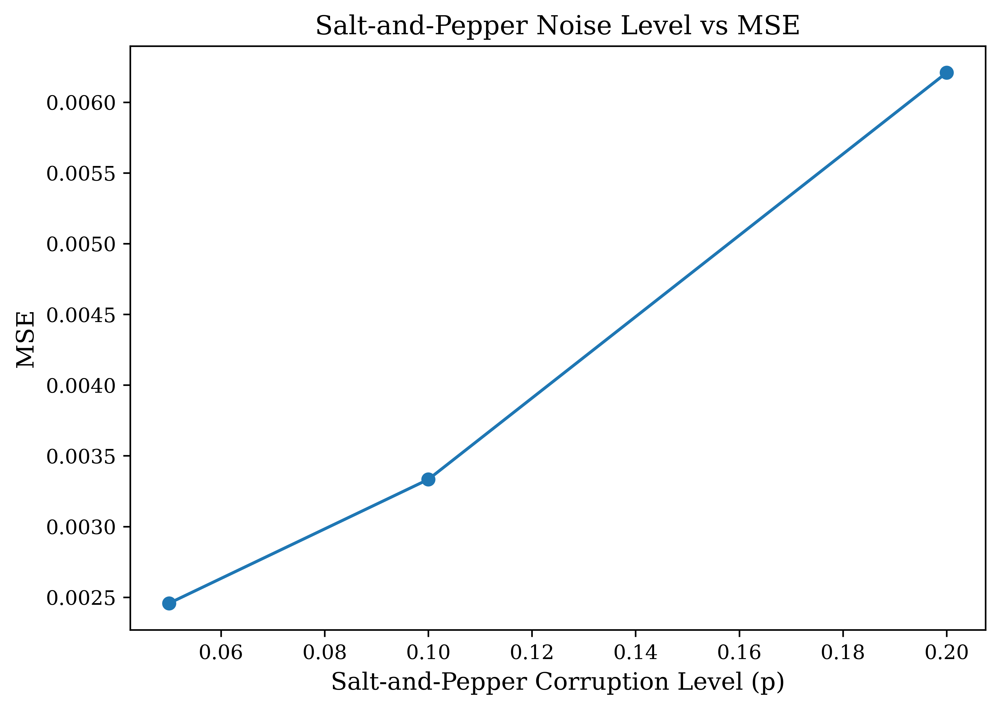

Saved: /content/lab7_outputs/06_sp_noise_vs_mae.eps


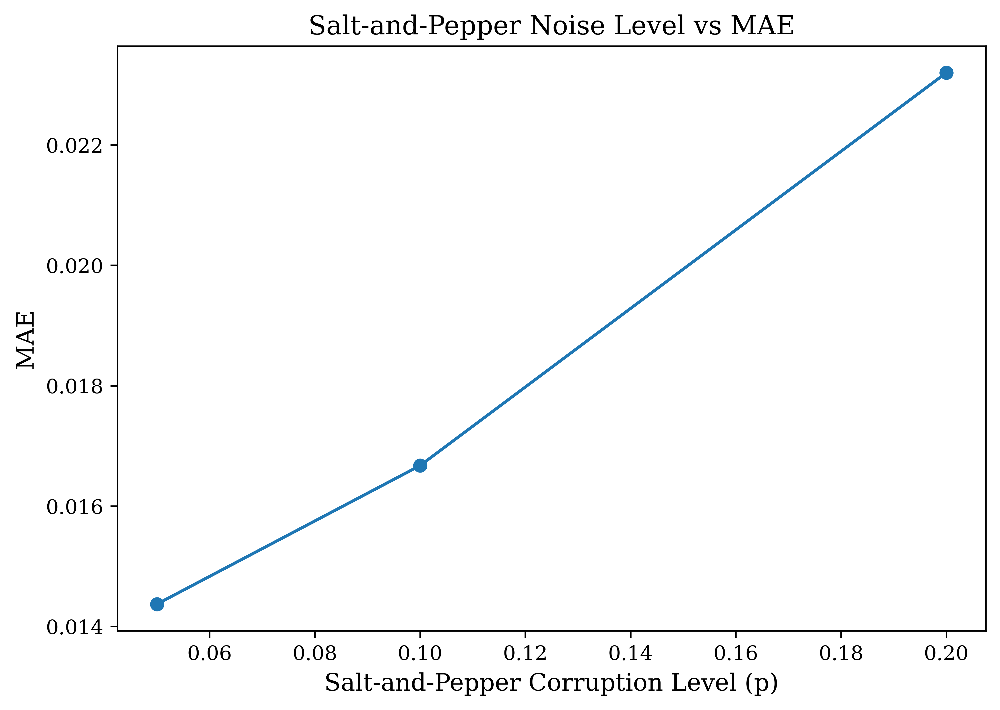

Saved: /content/lab7_outputs/06_sp_noise_vs_ssim.eps


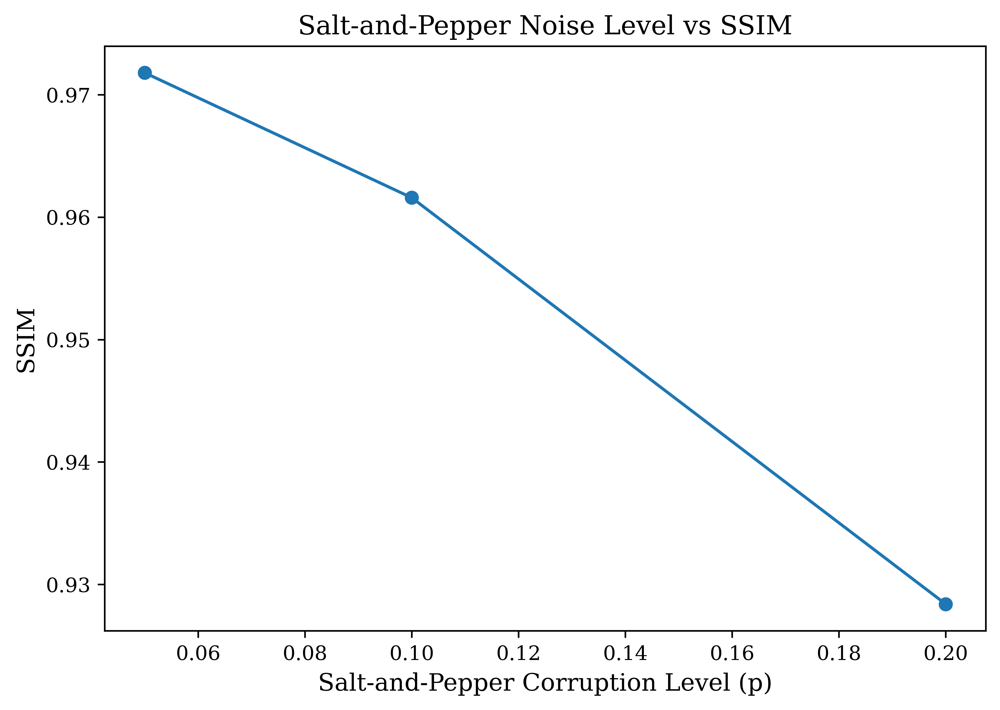

In [19]:

# ===== CELL 17: Salt-and-pepper noise evaluation =====
sp_metric_rows = []

for p, noisy_images in sp_test_sets.items():
    denoised = dae.predict(noisy_images, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, mean_ssim, _ = reconstruction_metrics(x_test, denoised)
    sp_metric_rows.append([p, mse, mae, mean_ssim])

sp_metrics_df = pd.DataFrame(
    sp_metric_rows,
    columns=["Noise Level (p)", "MSE", "MAE", "SSIM"]
)

display(sp_metrics_df)


# Required salt-and-pepper noise-level plots
for metric in ["MSE", "MAE", "SSIM"]:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        sp_metrics_df["Noise Level (p)"],
        sp_metrics_df[metric],
        marker="o"
    )
    ax.set_xlabel("Salt-and-Pepper Corruption Level (p)")
    ax.set_ylabel(metric)
    ax.set_title(f"Salt-and-Pepper Noise Level vs {metric}")
    fig.tight_layout()
    save_plot(fig, f"06_sp_noise_vs_{metric.lower()}")
    plt.show()


In [20]:

# ===== CELL 18: VAE implementation =====
class VAE(tf.keras.Model):
    def __init__(self, latent_dim=2, name="VAE", **kwargs):
        super().__init__(name=name, **kwargs)
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_conv1 = layers.Conv2D(
            32, 3, strides=2, activation="relu", padding="same"
        )
        self.encoder_conv2 = layers.Conv2D(
            64, 3, strides=2, activation="relu", padding="same"
        )
        self.encoder_flatten = layers.Flatten()
        self.encoder_dense = layers.Dense(128, activation="relu")
        self.z_mean_layer = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var_layer = layers.Dense(latent_dim, name="z_log_var")

        # Decoder
        self.decoder_dense = layers.Dense(7 * 7 * 64, activation="relu")
        self.decoder_reshape = layers.Reshape((7, 7, 64))
        self.decoder_deconv1 = layers.Conv2DTranspose(
            64, 3, strides=2, activation="relu", padding="same"
        )
        self.decoder_deconv2 = layers.Conv2DTranspose(
            32, 3, strides=2, activation="relu", padding="same"
        )
        self.decoder_output = layers.Conv2D(
            1, 3, activation="sigmoid", padding="same"
        )

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def encode(self, x, training=False):
        x = self.encoder_conv1(x, training=training)
        x = self.encoder_conv2(x, training=training)
        x = self.encoder_flatten(x)
        x = self.encoder_dense(x, training=training)
        z_mean = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)

        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        return z_mean, z_log_var, z

    def decode(self, z, training=False):
        x = self.decoder_dense(z, training=training)
        x = self.decoder_reshape(x)
        x = self.decoder_deconv1(x, training=training)
        x = self.decoder_deconv2(x, training=training)
        return self.decoder_output(x, training=training)

    def call(self, inputs, training=False):
        z_mean, z_log_var, z = self.encode(inputs, training=training)
        reconstruction = self.decode(z, training=training)
        return reconstruction, z_mean, z_log_var

    def _loss_components(self, data, training=False):
        reconstruction, z_mean, z_log_var = self(data, training=training)

        # Sum BCE over pixels and average over the batch.
        bce = tf.keras.backend.binary_crossentropy(data, reconstruction)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(bce, axis=(1, 2))
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._loss_components(
                data, training=True
            )

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, reconstruction_loss, kl_loss = self._loss_components(
            data, training=False
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def reconstruct(self, x):
        reconstruction, _, _ = self(x, training=False)
        return reconstruction

    def encode_mean(self, x):
        z_mean, _, _ = self.encode(x, training=False)
        return z_mean

    def generate(self, z):
        return self.decode(z, training=False)


vae = VAE(latent_dim=2)
vae.compile(optimizer=optimizers.Adam(learning_rate=1e-3))

# Build once so the summary displays correctly.
_ = vae(x_train[:1])
vae.summary()


Model: "VAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (1, 14, 14, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (1, 7, 7, 64)          │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 3136)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_mean (Dense)                  │ (1, 2)                 │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_log_var (Dense)               │ (1, 2)                 │           258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 3136)              │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (1, 14, 14, 64)        │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (1, 28, 28, 32)        │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (1, 28, 28, 1)         │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,957 (1.85 MB)

 Trainable params: 485,957 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:

# ===== CELL 19: Train the VAE =====
t0 = time.time()

history_vae = vae.fit(
    x_train,
    x_train,
    validation_data=(x_test, x_test),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_VAE,
    verbose=1
)

vae_train_time = time.time() - t0

vae_recon = vae.reconstruct(x_test).numpy()

vae_mse, vae_mae, vae_ssim, vae_ssim_values = reconstruction_metrics(
    x_test, vae_recon
)

print(f"Training time: {vae_train_time:.2f} seconds")
print_metric_row("VAE", vae_mse, vae_mae, vae_ssim)

print(f"Final reconstruction loss: {history_vae.history['reconstruction_loss'][-1]:.6f}")
print(f"Final KL loss            : {history_vae.history['kl_loss'][-1]:.6f}")
print(f"Final total loss         : {history_vae.history['loss'][-1]:.6f}")


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - kl_loss: 4.1920 - loss: 203.2687 - reconstruction_loss: 199.0767 - val_kl_loss: 4.7081 - val_loss: 171.1340 - val_reconstruction_loss: 166.4258
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.1432 - loss: 162.8768 - reconstruction_loss: 157.7336 - val_kl_loss: 5.6793 - val_loss: 158.2812 - val_reconstruction_loss: 152.6018
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - kl_loss: 5.6037 - loss: 156.3533 - reconstruction_loss: 150.7498 - val_kl_loss: 6.1735 - val_loss: 155.6382 - val_reconstruction_loss: 149.4648
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 5.8112 - loss: 153.9253 - reconstruction_loss: 148.1140 - val_kl_loss: 5.9227 - val_loss: 152.9823 - val_reconstruction_loss: 147.0597
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 5.9450 - loss: 152.3145 - reconstruction_loss: 146.3695 - val_kl_loss: 6.2213 - val_loss: 151.8313 - val_reconstruction_loss: 145.6099
Epoch 6/

Saved: /content/lab7_outputs/07_vae_training_validation_reconstruction_loss.eps


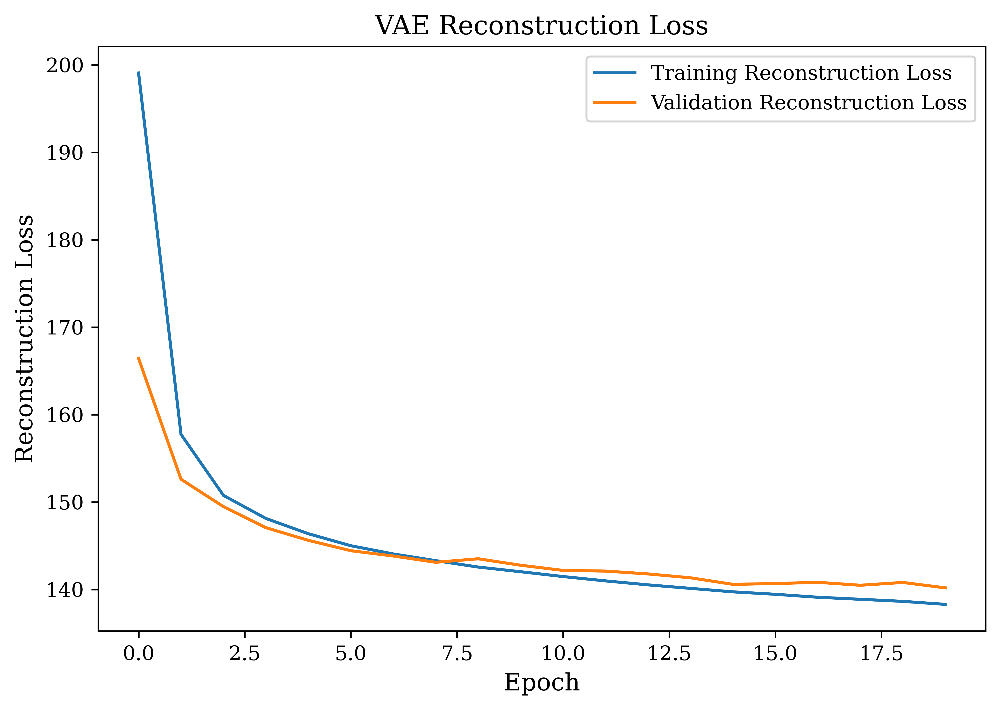

In [22]:

# ===== CELL 20: Plot 9 — VAE training/validation reconstruction loss =====
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    history_vae.history["reconstruction_loss"],
    label="Training Reconstruction Loss"
)
ax.plot(
    history_vae.history["val_reconstruction_loss"],
    label="Validation Reconstruction Loss"
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction Loss")
ax.set_title("VAE Reconstruction Loss")
ax.legend()
fig.tight_layout()
save_plot(fig, "07_vae_training_validation_reconstruction_loss")
plt.show()


Saved: /content/lab7_outputs/08_vae_latent_space.eps


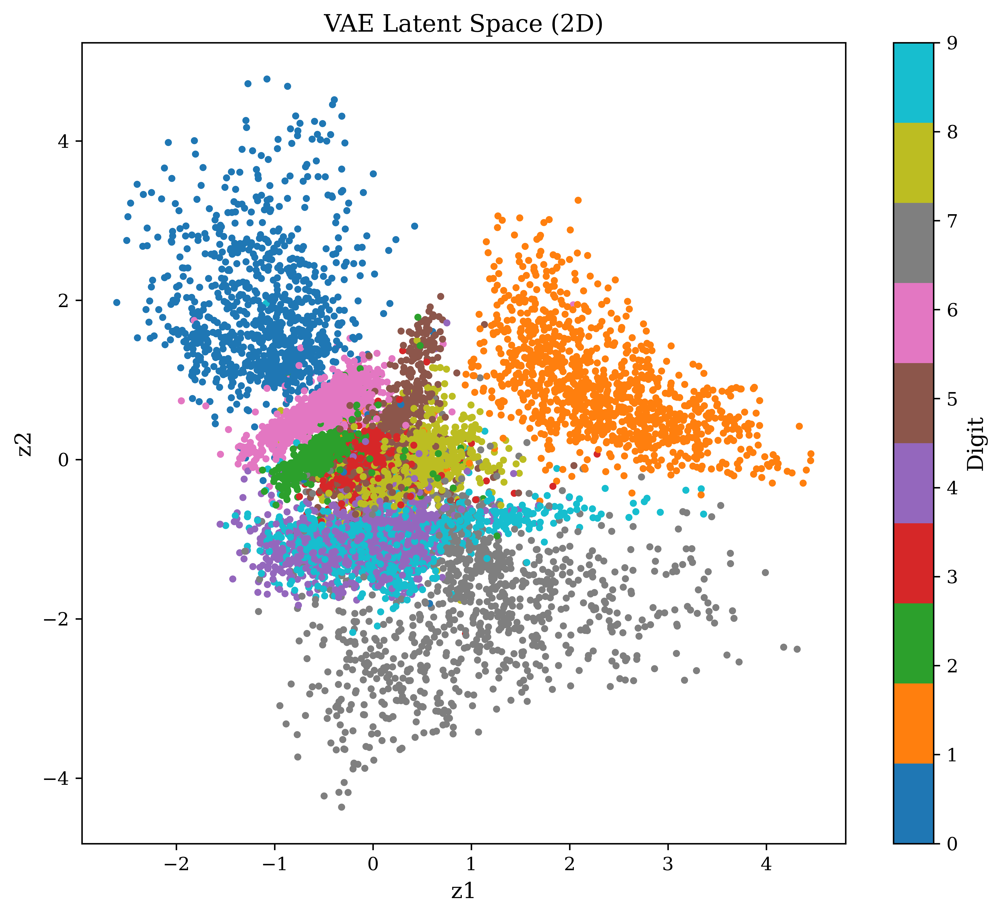

In [23]:

# ===== CELL 21: Plot 6 — VAE two-dimensional latent space =====
z_test = vae.encode_mean(x_test).numpy()

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(
    z_test[:, 0],
    z_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=8
)
ax.set_xlabel("z1")
ax.set_ylabel("z2")
ax.set_title("VAE Latent Space (2D)")
fig.colorbar(scatter, ax=ax, label="Digit")
fig.tight_layout()
save_plot(fig, "08_vae_latent_space")
plt.show()


Saved: /content/lab7_outputs/09_vae_generated_samples.eps


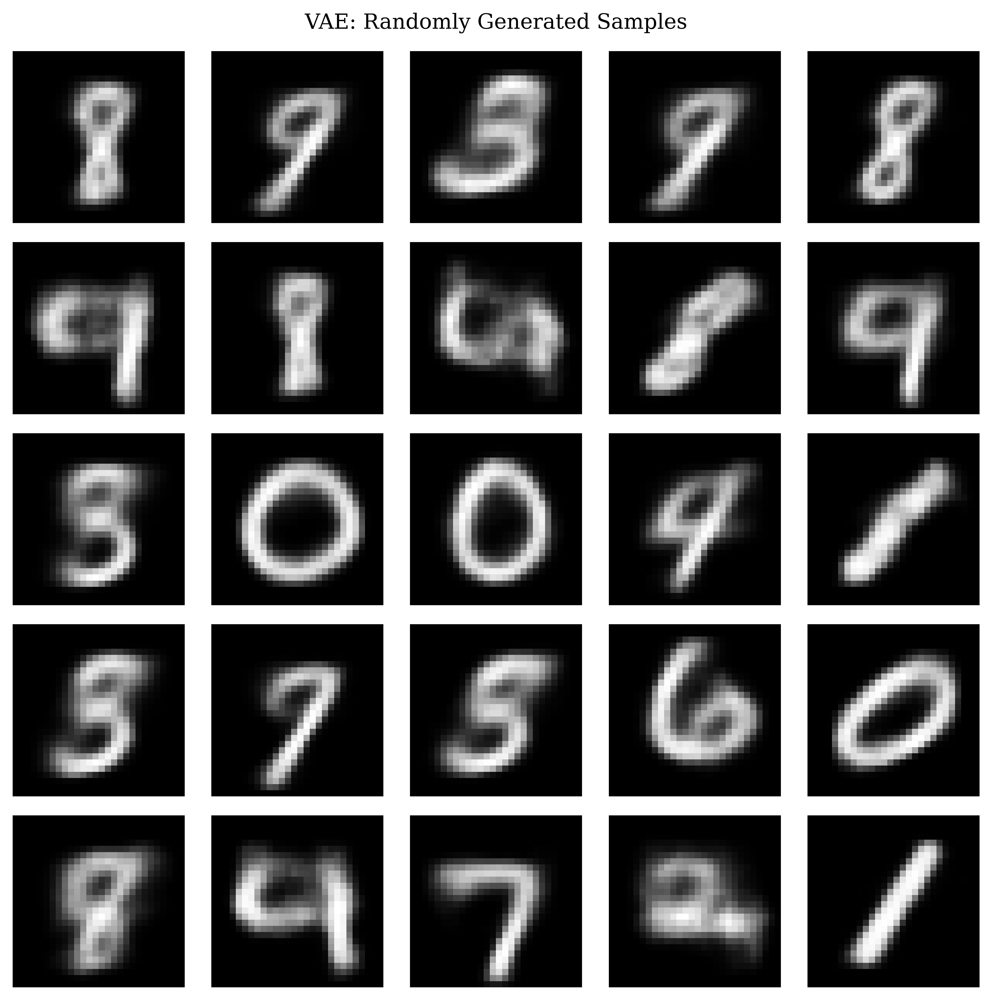

In [24]:

# ===== CELL 22: Plot 7 — Randomly generated VAE samples =====
random_latents = tf.random.normal(shape=(25, 2), seed=SEED)
generated_images = vae.generate(random_latents).numpy()

fig, axes = plt.subplots(5, 5, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze(), cmap="gray")
    ax.axis("off")

fig.suptitle("VAE: Randomly Generated Samples")
fig.tight_layout()
save_plot(fig, "09_vae_generated_samples")
plt.show()


Saved: /content/lab7_outputs/10_vae_latent_interpolation.eps




In [25]:

# ===== CELL 23: Plot 8 — Latent-space interpolation =====
# Select two latent points from encoded test images.
z_a = z_test[0]
z_b = z_test[1]

alphas = np.linspace(0.0, 1.0, 11)
interpolated_z = np.array([
    (1 - alpha) * z_a + alpha * z_b
    for alpha in alphas
], dtype="float32")

interpolated_images = vae.generate(interpolated_z).numpy()

fig, axes = plt.subplots(1, 11, figsize=(17, 2.5))

for i, ax in enumerate(axes):
    ax.imshow(interpolated_images[i].squeeze(), cmap="gray")
    ax.set_title(f"{alphas[i]:.1f}")
    ax.axis("off")

fig.suptitle("VAE Latent-Space Interpolation")
fig.tight_layout()
save_plot(fig, "10_vae_latent_interpolation")
plt.show()


Saved: /content/lab7_outputs/11_reconstruction_error_distribution.eps


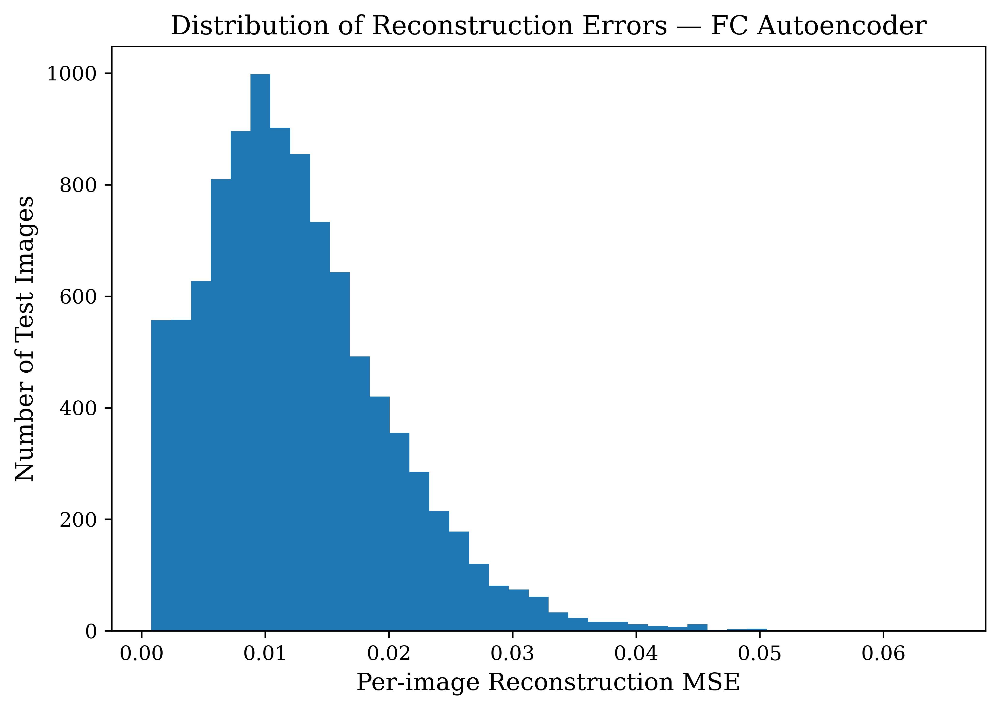

Mean error : 0.012522
Median error: 0.011413
Maximum error: 0.065048


In [26]:

# ===== CELL 24: Plot 10 — Reconstruction-error distribution =====
fc_errors = per_image_mse(x_test, fc_recon)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(fc_errors, bins=40)
ax.set_xlabel("Per-image Reconstruction MSE")
ax.set_ylabel("Number of Test Images")
ax.set_title("Distribution of Reconstruction Errors — FC Autoencoder")
fig.tight_layout()
save_plot(fig, "11_reconstruction_error_distribution")
plt.show()

print(f"Mean error : {fc_errors.mean():.6f}")
print(f"Median error: {np.median(fc_errors):.6f}")
print(f"Maximum error: {fc_errors.max():.6f}")


Saved: /content/lab7_outputs/12_five_high_error_samples.eps


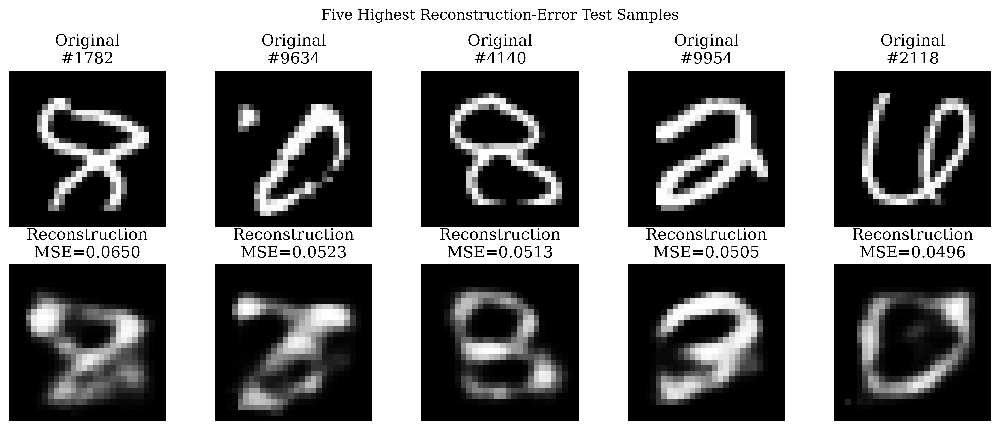

High-error sample indices: [1782, 9634, 4140, 9954, 2118]


In [27]:

# ===== CELL 25: Five highest-error test images =====
top5_idx = np.argsort(fc_errors)[-5:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for col, idx in enumerate(top5_idx):
    axes[0, col].imshow(x_test[idx].squeeze(), cmap="gray")
    axes[0, col].set_title(f"Original\n#{idx}")
    axes[0, col].axis("off")

    axes[1, col].imshow(fc_recon[idx].squeeze(), cmap="gray")
    axes[1, col].set_title(f"Reconstruction\nMSE={fc_errors[idx]:.4f}")
    axes[1, col].axis("off")

fig.suptitle("Five Highest Reconstruction-Error Test Samples")
fig.tight_layout()
save_plot(fig, "12_five_high_error_samples")
plt.show()

print("High-error sample indices:", top5_idx.tolist())


In [28]:

# ===== CELL 26: Consolidated reconstruction metrics =====
reconstruction_results = pd.DataFrame([
    {
        "Model": "FC Autoencoder",
        "MSE": fc_mse,
        "MAE": fc_mae,
        "SSIM": fc_ssim,
        "Parameters": fc_autoencoder.count_params(),
        "Training Time (s)": fc_train_time,
    },
    {
        "Model": "Convolutional AE",
        "MSE": cae_mse,
        "MAE": cae_mae,
        "SSIM": cae_ssim,
        "Parameters": cae.count_params(),
        "Training Time (s)": cae_train_time,
    },
    {
        "Model": "Denoising CAE",
        "MSE": dae_mse,
        "MAE": dae_mae,
        "SSIM": dae_ssim,
        "Parameters": dae.count_params(),
        "Training Time (s)": dae_train_time,
    },
])

display(reconstruction_results)

vae_results = pd.DataFrame([{
    "VAE Reconstruction Loss": history_vae.history["reconstruction_loss"][-1],
    "VAE KL Loss": history_vae.history["kl_loss"][-1],
    "VAE Total Loss": history_vae.history["loss"][-1],
    "Test MSE": vae_mse,
    "Test MAE": vae_mae,
    "Mean SSIM": vae_ssim,
    "Parameters": vae.count_params(),
    "Training Time (s)": vae_train_time,
}])

display(vae_results)


,Model,MSE,MAE,SSIM,Parameters,Training Time (s)
0,FC Autoencoder,0.012522,0.038683,0.860983,211040,45.243976
1,Convolutional AE,0.001112,0.009915,0.989294,74497,76.691047
2,Denoising CAE,0.003320,0.017802,0.958926,74497,74.412570


,VAE Reconstruction Loss,VAE KL Loss,VAE Total Loss,Test MSE,Test MAE,Mean SSIM,Parameters,Training Time (s)
0,138.289749,6.589109,144.878815,0.039313,0.093964,0.564164,485957,83.451032


In [29]:

# ===== CELL 27: Latent-dimension experiment =====
def build_fc_autoencoder(latent_dim):
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(latent_dim, activation="relu", name=f"latent_{latent_dim}"),
        layers.Dense(32, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(784, activation="sigmoid"),
        layers.Reshape((28, 28, 1))
    ], name=f"FC_AE_latent_{latent_dim}")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy"
    )
    return model


latent_dims = [2, 8, 16, 32]
latent_results = []

for latent_dim in latent_dims:
    print(f"\nTraining latent dimension = {latent_dim}")

    m = build_fc_autoencoder(latent_dim)
    t0 = time.time()

    h = m.fit(
        x_train, x_train,
        validation_data=(x_test, x_test),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS_LATENT,
        verbose=0
    )

    elapsed = time.time() - t0
    recon = m.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    mse, mae, mean_ssim, _ = reconstruction_metrics(x_test, recon)

    latent_results.append({
        "Latent Dimension": latent_dim,
        "MSE": mse,
        "SSIM": mean_ssim,
        "Parameters": m.count_params(),
        "Training Time (s)": elapsed,
    })

    print_metric_row(f"Latent {latent_dim}", mse, mae, mean_ssim)

latent_results_df = pd.DataFrame(latent_results)
display(latent_results_df)



Training latent dimension = 2
Latent 2                  MSE=0.039981 | MAE=0.094815 | SSIM=0.560988

Training latent dimension = 8
Latent 8                  MSE=0.021923 | MAE=0.058417 | SSIM=0.753683

Training latent dimension = 16
Latent 16                 MSE=0.013602 | MAE=0.041062 | SSIM=0.847373

Training latent dimension = 32
Latent 32                 MSE=0.011093 | MAE=0.035548 | SSIM=0.878561


,Latent Dimension,MSE,SSIM,Parameters,Training Time (s)
0,2,0.039981,0.560988,210130,38.485292
1,8,0.021923,0.753683,210520,37.633577
2,16,0.013602,0.847373,211040,38.597634
3,32,0.011093,0.878561,212080,38.670043


Saved: /content/lab7_outputs/13_latent_dimension_vs_mse.eps


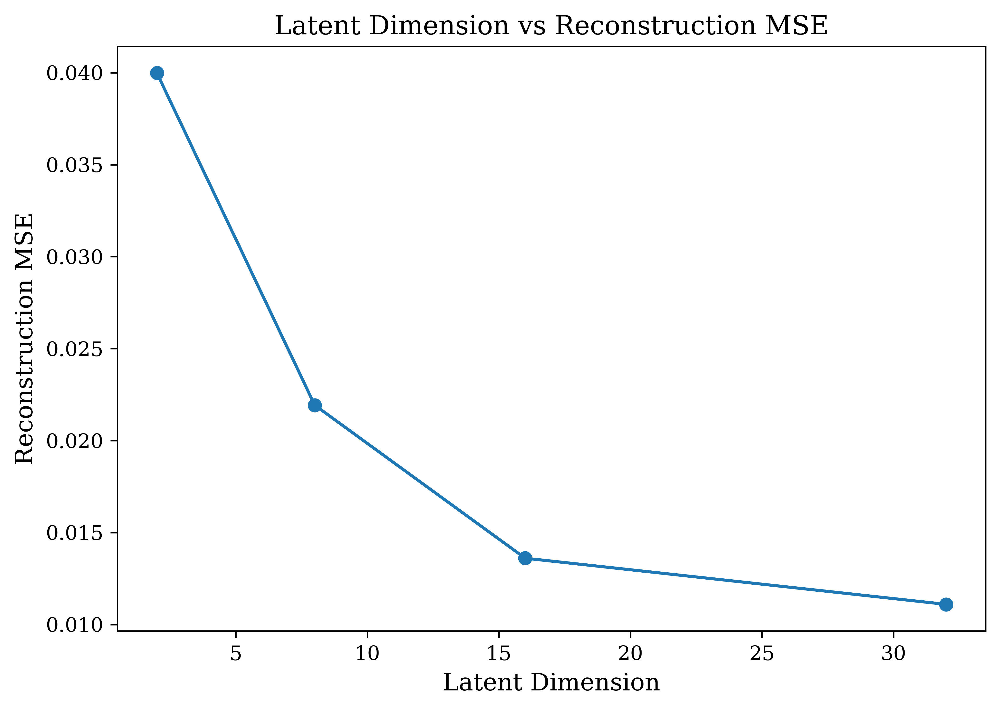

Saved: /content/lab7_outputs/14_latent_dimension_vs_ssim.eps


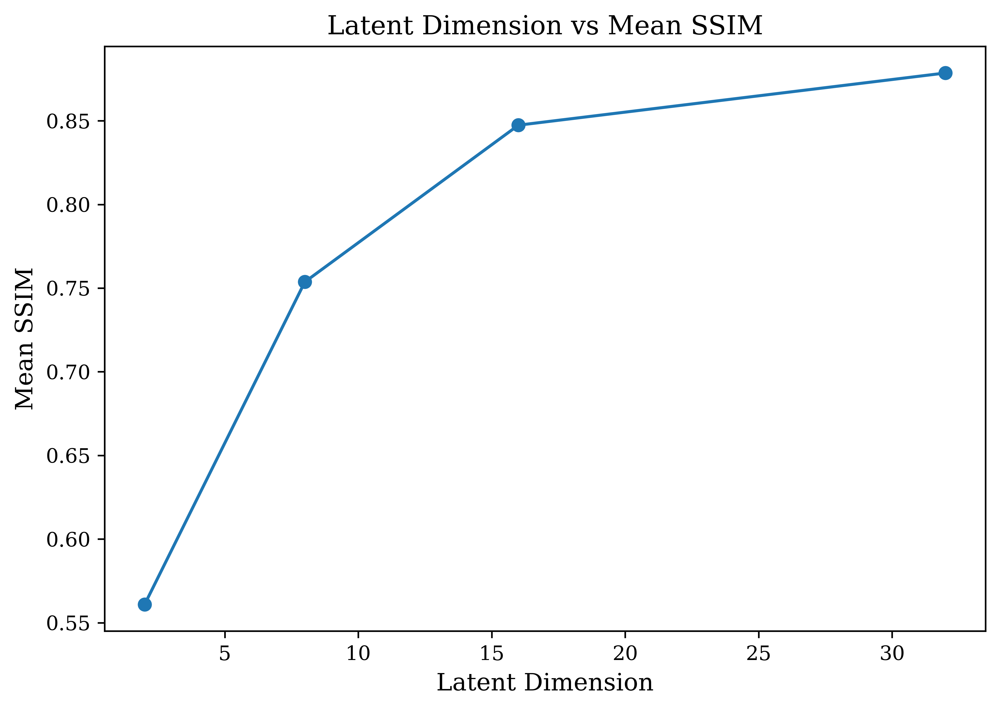

In [30]:

# ===== CELL 28: Plot 10 — Latent dimension vs reconstruction MSE =====
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    latent_results_df["Latent Dimension"],
    latent_results_df["MSE"],
    marker="o"
)
ax.set_xlabel("Latent Dimension")
ax.set_ylabel("Reconstruction MSE")
ax.set_title("Latent Dimension vs Reconstruction MSE")
fig.tight_layout()
save_plot(fig, "13_latent_dimension_vs_mse")
plt.show()

# SSIM is also useful for the required latent-dimension table.
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    latent_results_df["Latent Dimension"],
    latent_results_df["SSIM"],
    marker="o"
)
ax.set_xlabel("Latent Dimension")
ax.set_ylabel("Mean SSIM")
ax.set_title("Latent Dimension vs Mean SSIM")
fig.tight_layout()
save_plot(fig, "14_latent_dimension_vs_ssim")
plt.show()


In [31]:

# ===== CELL 29: VAE loss summary and complete result tables =====
print("VAE Loss Components")
print("-" * 45)
print(f"Reconstruction Loss : {history_vae.history['reconstruction_loss'][-1]:.6f}")
print(f"KL Loss             : {history_vae.history['kl_loss'][-1]:.6f}")
print(f"Total Loss          : {history_vae.history['loss'][-1]:.6f}")
print()

print("VAE Test Reconstruction Metrics")
print("-" * 45)
print(f"Test MSE            : {vae_mse:.6f}")
print(f"Test MAE            : {vae_mae:.6f}")
print(f"Mean SSIM           : {vae_ssim:.6f}")


VAE Loss Components
---------------------------------------------
Reconstruction Loss : 138.289749
KL Loss             : 6.589109
Total Loss          : 144.878815

VAE Test Reconstruction Metrics
---------------------------------------------
Test MSE            : 0.039313
Test MAE            : 0.093964
Mean SSIM           : 0.564164


In [32]:

# ===== CELL 30: Save measured tables and all experiment summaries =====
reconstruction_results.to_csv(
    os.path.join(PLOT_DIR, "reconstruction_model_comparison.csv"),
    index=False
)

gaussian_metrics_df.to_csv(
    os.path.join(PLOT_DIR, "gaussian_noise_metrics.csv"),
    index=False
)

sp_metrics_df.to_csv(
    os.path.join(PLOT_DIR, "salt_pepper_metrics.csv"),
    index=False
)

latent_results_df.to_csv(
    os.path.join(PLOT_DIR, "latent_dimension_study.csv"),
    index=False
)

vae_results.to_csv(
    os.path.join(PLOT_DIR, "vae_metrics.csv"),
    index=False
)

print("Saved result tables:")
for filename in sorted(os.listdir(PLOT_DIR)):
    if filename.endswith(".csv"):
        print(" -", filename)


Saved result tables:
 - gaussian_noise_metrics.csv
 - latent_dimension_study.csv
 - reconstruction_model_comparison.csv
 - salt_pepper_metrics.csv
 - vae_metrics.csv


In [33]:

# ===== CELL 31: Package all EPS figures and result tables =====
zip_base = "/content/CS3807_Experiment_7_outputs"
shutil.make_archive(zip_base, "zip", PLOT_DIR)

print("Files included in the archive:")
for filename in sorted(os.listdir(PLOT_DIR)):
    print(" -", filename)

print(f"\nArchive created: {zip_base}.zip")

# Uncomment the next two lines in Google Colab if you want the browser download dialog.
# from google.colab import files
# files.download(zip_base + ".zip")


Files included in the archive:
 - 01_sample_mnist_images.eps
 - 02_fc_original_vs_reconstruction.eps
 - 03_fc_training_validation_loss.eps
 - 04_fc_vs_cae_reconstruction.eps
 - 05_clean_noisy_denoised.eps
 - 06_gaussian_noise_vs_mae.eps
 - 06_gaussian_noise_vs_mse.eps
 - 06_gaussian_noise_vs_ssim.eps
 - 06_sp_noise_vs_mae.eps
 - 06_sp_noise_vs_mse.eps
 - 06_sp_noise_vs_ssim.eps
 - 07_vae_training_validation_reconstruction_loss.eps
 - 08_vae_latent_space.eps
 - 09_vae_generated_samples.eps
 - 10_vae_latent_interpolation.eps
 - 11_reconstruction_error_distribution.eps
 - 12_five_high_error_samples.eps
 - 13_latent_dimension_vs_mse.eps
 - 14_latent_dimension_vs_ssim.eps
 - gaussian_noise_metrics.csv
 - latent_dimension_study.csv
 - reconstruction_model_comparison.csv
 - salt_pepper_metrics.csv
 - vae_metrics.csv

Archive created: /content/CS3807_Experiment_7_outputs.zip


In [34]:
# ============================================================
# ADDITIONAL EXERCISES
# These experiments intentionally use a smaller MNIST subset.
# Main experiment above uses the full MNIST training/test sets.
# ============================================================

x_add_train = x_train[:ADD_N_TRAIN]
y_add_train = y_train[:ADD_N_TRAIN]
x_add_test = x_test[:ADD_N_TEST]
y_add_test = y_test[:ADD_N_TEST]

print("Additional-exercise subset:", x_add_train.shape, x_add_test.shape)


Additional-exercise subset: (2000, 28, 28, 1) (500, 28, 28, 1)


Training CAE latent dimension 4
Training CAE latent dimension 8


Training CAE latent dimension 16
Training CAE latent dimension 32


,Latent Dimension,MSE,MAE,SSIM,Parameters,Training Time (s)
0,4,0.062959,0.144194,0.196654,102725,9.617898
1,8,0.061179,0.141162,0.208400,127817,8.783337
2,16,0.058271,0.134567,0.256739,178001,7.969401
3,32,0.052818,0.120926,0.346751,278369,8.210963


Saved: /content/lab7_outputs/15_add_cae_latent_dimension_mse.eps


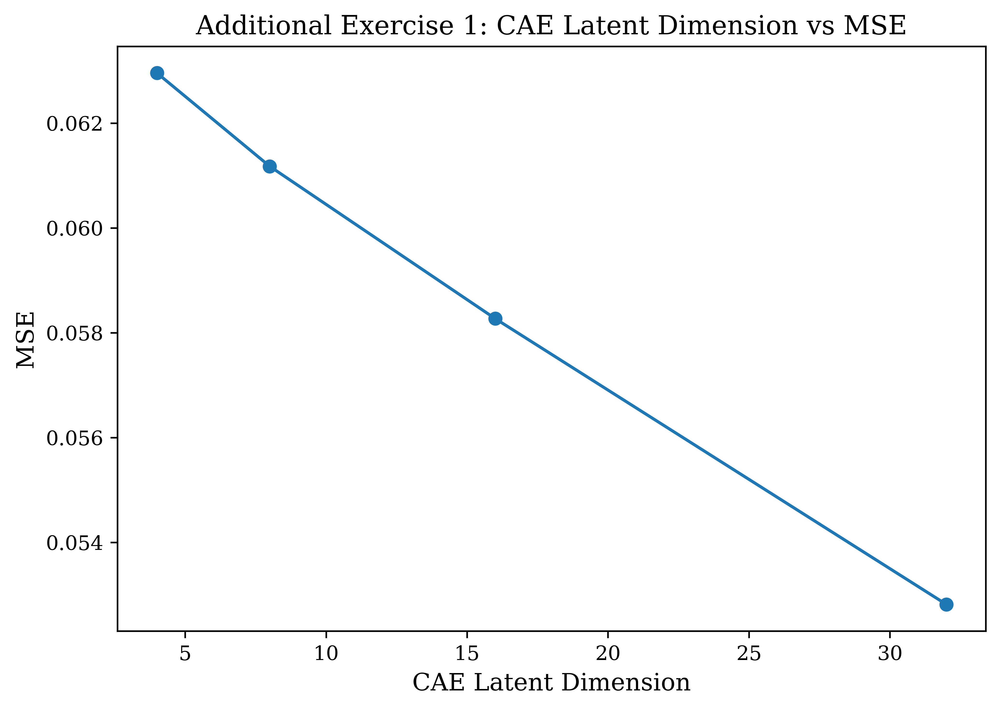

In [36]:
# ============================================================
# Additional Exercise 1
# Train a convolutional autoencoder with latent dimensions 4, 8, 16 and 32.
# ============================================================

def build_cae_dense_latent(latent_dim, name=None, transpose_decoder=False):
    name = name or f"CAE_latent_{latent_dim}"
    inp = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    shape_before = (7, 7, 64)
    x = layers.Flatten()(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(int(np.prod(shape_before)), activation="relu")(z)
    x = layers.Reshape(shape_before)(x)
    if transpose_decoder:
        x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
        x = layers.Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(x)
    else:
        x = layers.UpSampling2D(2)(x)
        x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
        x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    model = models.Model(inp, out, name=name)
    model.compile(optimizer=optimizers.Adam(1e-3), loss="binary_crossentropy")
    return model

cae_latent_models = {}
cae_latent_rows = []
for d in [4, 8, 16, 32]:
    print(f"Training CAE latent dimension {d}")
    m = build_cae_dense_latent(d)
    t0 = time.time()
    m.fit(x_add_train, x_add_train, validation_data=(x_add_test, x_add_test),
          batch_size=ADD_BATCH_SIZE, epochs=ADD_EPOCHS, verbose=0)
    elapsed = time.time() - t0
    pred = m.predict(x_add_test, batch_size=ADD_BATCH_SIZE, verbose=0)
    mse, mae, mean_ssim, _ = reconstruction_metrics(x_add_test, pred)
    cae_latent_models[d] = m
    cae_latent_rows.append([d, mse, mae, mean_ssim, m.count_params(), elapsed])

cae_latent_results = pd.DataFrame(
    cae_latent_rows,
    columns=["Latent Dimension", "MSE", "MAE", "SSIM", "Parameters", "Training Time (s)"]
)
display(cae_latent_results)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(cae_latent_results["Latent Dimension"], cae_latent_results["MSE"], marker="o")
ax.set_xlabel("CAE Latent Dimension"); ax.set_ylabel("MSE")
ax.set_title("Additional Exercise 1: CAE Latent Dimension vs MSE")
fig.tight_layout(); save_plot(fig, "15_add_cae_latent_dimension_mse"); plt.show()


,Training Noise,MSE,MAE,SSIM
0,Gaussian (sigma=0.2),0.019066,0.053288,0.790133
1,Salt-and-pepper (p=0.1),0.020963,0.057362,0.767574


,Gaussian Sigma,MSE,MAE,SSIM
0,0.1,0.017272,0.048167,0.821626
1,0.3,0.021824,0.059959,0.743964


Saved: /content/lab7_outputs/16_add_noise_level_vs_ssim.eps


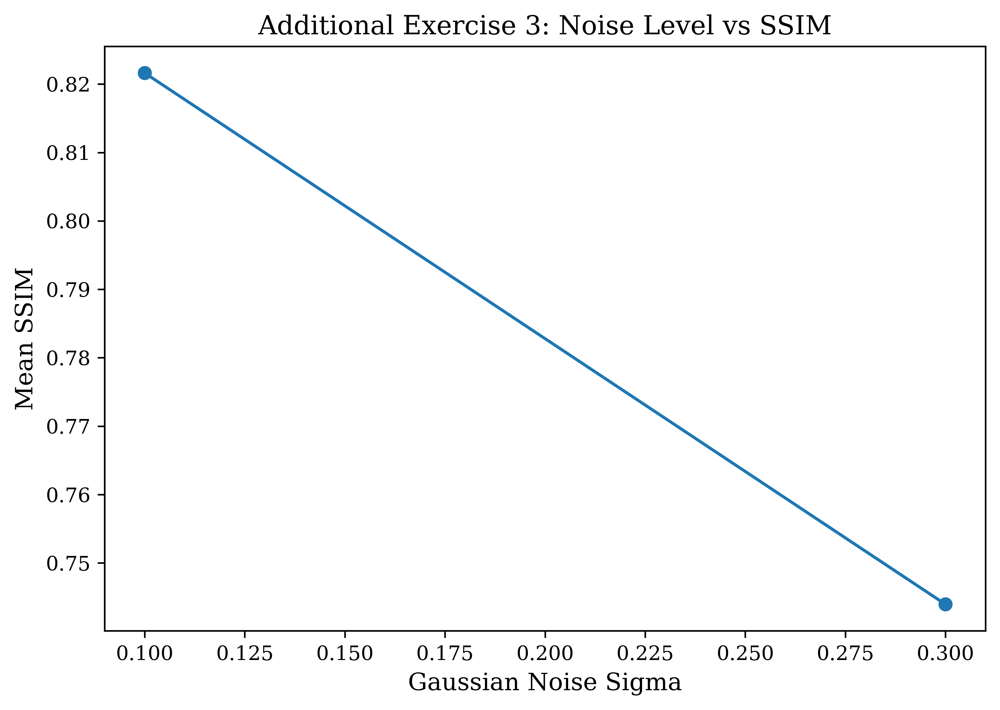

In [37]:
# ============================================================
# Additional Exercises 2 and 3
# Compare Gaussian and salt-and-pepper noise using the same DAE architecture,
# then compare two Gaussian noise levels using SSIM.
# ============================================================

def train_additional_dae(noisy_train, epochs=ADD_EPOCHS, name="Additional_DAE"):
    m = build_cae(name=name)
    m.fit(noisy_train, x_add_train,
          validation_data=(x_add_test, x_add_test),
          batch_size=ADD_BATCH_SIZE, epochs=epochs, verbose=0)
    return m

gauss_add_train = add_gaussian_noise(x_add_train, sigma=0.2, seed=310)
sp_add_train = add_salt_pepper_noise(x_add_train, p=0.1, seed=311)

dae_gauss_add = train_additional_dae(gauss_add_train, name="DAE_Gaussian")
dae_sp_add = train_additional_dae(sp_add_train, name="DAE_SaltPepper")

gauss_eval = add_gaussian_noise(x_add_test, sigma=0.2, seed=312)
sp_eval = add_salt_pepper_noise(x_add_test, p=0.1, seed=313)

g_pred = dae_gauss_add.predict(gauss_eval, batch_size=ADD_BATCH_SIZE, verbose=0)
s_pred = dae_sp_add.predict(sp_eval, batch_size=ADD_BATCH_SIZE, verbose=0)
g_mse, g_mae, g_ssim, _ = reconstruction_metrics(x_add_test, g_pred)
s_mse, s_mae, s_ssim, _ = reconstruction_metrics(x_add_test, s_pred)

noise_type_results = pd.DataFrame([
    ["Gaussian (sigma=0.2)", g_mse, g_mae, g_ssim],
    ["Salt-and-pepper (p=0.1)", s_mse, s_mae, s_ssim]
], columns=["Training Noise", "MSE", "MAE", "SSIM"])
display(noise_type_results)

# Additional Exercise 3: two Gaussian noise levels and SSIM comparison.
noise_level_rows = []
for sigma in [0.1, 0.3]:
    noisy = add_gaussian_noise(x_add_test, sigma=sigma, seed=320 + int(sigma*100))
    pred = dae_gauss_add.predict(noisy, batch_size=ADD_BATCH_SIZE, verbose=0)
    mse, mae, mean_ssim, _ = reconstruction_metrics(x_add_test, pred)
    noise_level_rows.append([sigma, mse, mae, mean_ssim])

gradient_noise_results = pd.DataFrame(noise_level_rows, columns=["Gaussian Sigma", "MSE", "MAE", "SSIM"])
display(gradient_noise_results)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(gradient_noise_results["Gaussian Sigma"], gradient_noise_results["SSIM"], marker="o")
ax.set_xlabel("Gaussian Noise Sigma"); ax.set_ylabel("Mean SSIM")
ax.set_title("Additional Exercise 3: Noise Level vs SSIM")
fig.tight_layout(); save_plot(fig, "16_add_noise_level_vs_ssim"); plt.show()


,Decoder,MSE,MAE,SSIM
0,UpSampling2D,0.055904,0.130560,0.287289
1,Conv2DTranspose,0.065726,0.150415,0.162916


Saved: /content/lab7_outputs/17_add_decoder_comparison.eps


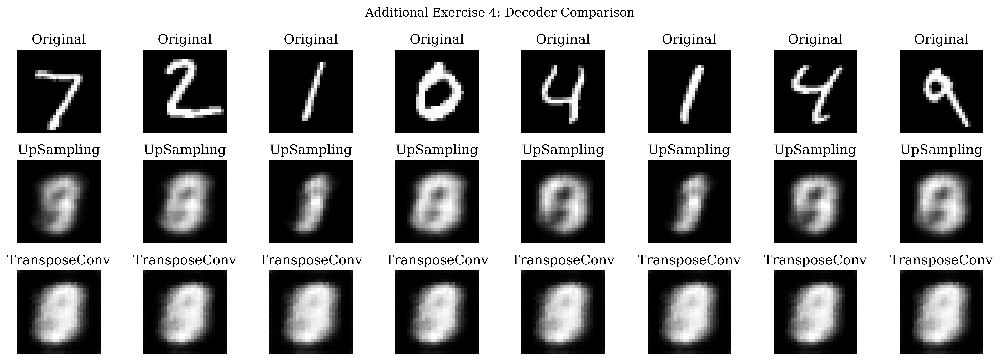

In [38]:
# ============================================================
# Additional Exercise 4
# Replace the upsampling decoder with transposed convolutions and compare.
# ============================================================

cae_upsample = build_cae_dense_latent(16, name="CAE_Upsampling", transpose_decoder=False)
cae_transpose = build_cae_dense_latent(16, name="CAE_TransposeConv", transpose_decoder=True)

for model in [cae_upsample, cae_transpose]:
    model.fit(x_add_train, x_add_train,
              validation_data=(x_add_test, x_add_test),
              batch_size=ADD_BATCH_SIZE, epochs=ADD_EPOCHS, verbose=0)

up_pred = cae_upsample.predict(x_add_test, batch_size=ADD_BATCH_SIZE, verbose=0)
tr_pred = cae_transpose.predict(x_add_test, batch_size=ADD_BATCH_SIZE, verbose=0)
up_mse, up_mae, up_ssim, _ = reconstruction_metrics(x_add_test, up_pred)
tr_mse, tr_mae, tr_ssim, _ = reconstruction_metrics(x_add_test, tr_pred)

decoder_results = pd.DataFrame([
    ["UpSampling2D", up_mse, up_mae, up_ssim],
    ["Conv2DTranspose", tr_mse, tr_mae, tr_ssim]
], columns=["Decoder", "MSE", "MAE", "SSIM"])
display(decoder_results)

fig, axes = plt.subplots(3, 8, figsize=(14,5))
for i in range(8):
    axes[0,i].imshow(x_add_test[i].squeeze(), cmap="gray"); axes[0,i].axis("off"); axes[0,i].set_title("Original")
    axes[1,i].imshow(up_pred[i].squeeze(), cmap="gray"); axes[1,i].axis("off"); axes[1,i].set_title("UpSampling")
    axes[2,i].imshow(tr_pred[i].squeeze(), cmap="gray"); axes[2,i].axis("off"); axes[2,i].set_title("TransposeConv")
fig.suptitle("Additional Exercise 4: Decoder Comparison")
fig.tight_layout(); save_plot(fig, "17_add_decoder_comparison"); plt.show()


Training VAE latent dimension 2
Training VAE latent dimension 8


,Latent Dimension,Reconstruction Loss,KL Loss,Total Loss,Test MSE,Test MAE,Mean SSIM,Training Time (s)
0,2,206.500534,2.280629,208.781128,0.063376,0.143759,0.189010,10.981811
1,8,207.338913,4.138688,211.477600,0.064696,0.149082,0.174045,10.039828


Saved: /content/lab7_outputs/18_add_vae_latent_2_vs_8.eps


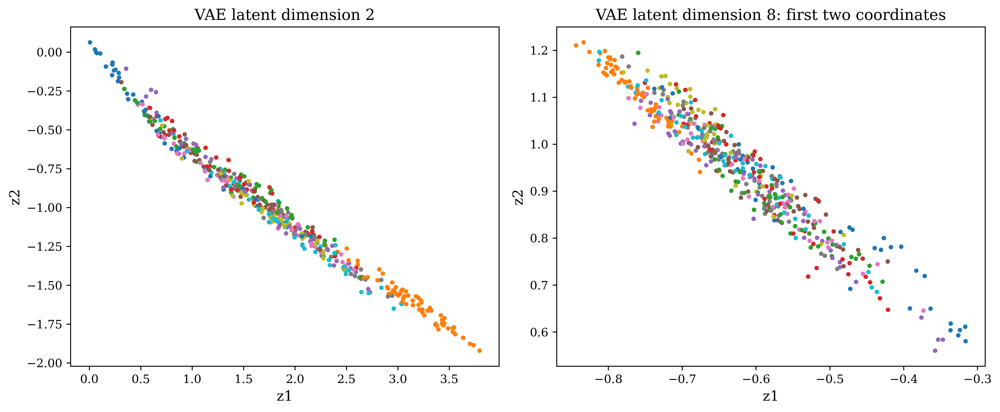

In [39]:
# ============================================================
# Additional Exercise 5
# Compare VAE latent dimensions 2 and 8.
# ============================================================

vae_latent_models = {}
vae_latent_rows = []
for d in [2, 8]:
    print(f"Training VAE latent dimension {d}")
    v = VAE(latent_dim=d, name=f"VAE_latent_{d}")
    v.compile(optimizer=optimizers.Adam(1e-3))
    _ = v(x_add_train[:1])
    t0 = time.time()
    h = v.fit(x_add_train, x_add_train,
              validation_data=(x_add_test, x_add_test),
              batch_size=ADD_BATCH_SIZE, epochs=ADD_EPOCHS, verbose=0)
    elapsed = time.time() - t0
    pred = v.reconstruct(x_add_test).numpy()
    mse, mae, mean_ssim, _ = reconstruction_metrics(x_add_test, pred)
    vae_latent_models[d] = v
    vae_latent_rows.append([d, h.history["reconstruction_loss"][-1], h.history["kl_loss"][-1],
                            h.history["loss"][-1], mse, mae, mean_ssim, elapsed])

vae_latent_results = pd.DataFrame(
    vae_latent_rows,
    columns=["Latent Dimension", "Reconstruction Loss", "KL Loss", "Total Loss",
             "Test MSE", "Test MAE", "Mean SSIM", "Training Time (s)"]
)
display(vae_latent_results)

z2 = vae_latent_models[2].encode_mean(x_add_test).numpy()
z8 = vae_latent_models[8].encode_mean(x_add_test).numpy()
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(z2[:,0], z2[:,1], c=y_add_test, s=8, cmap="tab10"); axes[0].set_title("VAE latent dimension 2")
axes[0].set_xlabel("z1"); axes[0].set_ylabel("z2")
axes[1].scatter(z8[:,0], z8[:,1], c=y_add_test, s=8, cmap="tab10")
axes[1].set_title("VAE latent dimension 8: first two coordinates")
axes[1].set_xlabel("z1"); axes[1].set_ylabel("z2")
fig.tight_layout(); save_plot(fig, "18_add_vae_latent_2_vs_8"); plt.show()


In [40]:
# ============================================================
# Additional Exercise 6
# Investigate the effect of increasing KL-loss contribution (beta-VAE style).
# ============================================================

class BetaVAE(VAE):
    def __init__(self, latent_dim=2, beta=1.0, name="BetaVAE", **kwargs):
        super().__init__(latent_dim=latent_dim, name=name, **kwargs)
        self.beta = beta

    def _loss_components(self, data, training=False):
        reconstruction, z_mean, z_log_var = self(data, training=training)
        bce = tf.keras.backend.binary_crossentropy(data, reconstruction)
        reconstruction_loss = tf.reduce_mean(tf.reduce_sum(bce, axis=(1,2)))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss

beta_rows = []
beta_models = {}
for beta in [0.1, 1.0, 2.0]:
    print(f"Training beta-VAE beta={beta}")
    v = BetaVAE(latent_dim=2, beta=beta, name=f"BetaVAE_{beta}")
    v.compile(optimizer=optimizers.Adam(1e-3))
    _ = v(x_add_train[:1])
    h = v.fit(x_add_train, x_add_train,
              validation_data=(x_add_test, x_add_test),
              batch_size=ADD_BATCH_SIZE, epochs=ADD_EPOCHS, verbose=0)
    pred = v.reconstruct(x_add_test).numpy()
    mse, mae, mean_ssim, _ = reconstruction_metrics(x_add_test, pred)
    beta_models[beta] = v
    beta_rows.append([beta, h.history["reconstruction_loss"][-1], h.history["kl_loss"][-1],
                      h.history["loss"][-1], mse, mae, mean_ssim])

beta_results = pd.DataFrame(beta_rows, columns=["Beta", "Reconstruction Loss", "KL Loss", "Weighted Total Loss",
                                                 "Test MSE", "Test MAE", "Mean SSIM"])
display(beta_results)


Training beta-VAE beta=0.1
Training beta-VAE beta=1.0
Training beta-VAE beta=2.0


,Beta,Reconstruction Loss,KL Loss,Weighted Total Loss,Test MSE,Test MAE,Mean SSIM
0,0.1,209.367493,2.527217,209.620224,0.064191,0.146144,0.184761
1,1.0,204.856964,3.332363,208.189362,0.063220,0.143592,0.191279
2,2.0,200.710342,2.146256,205.002838,0.061999,0.141898,0.218064


Saved: /content/lab7_outputs/19_add_vae_100_samples.eps


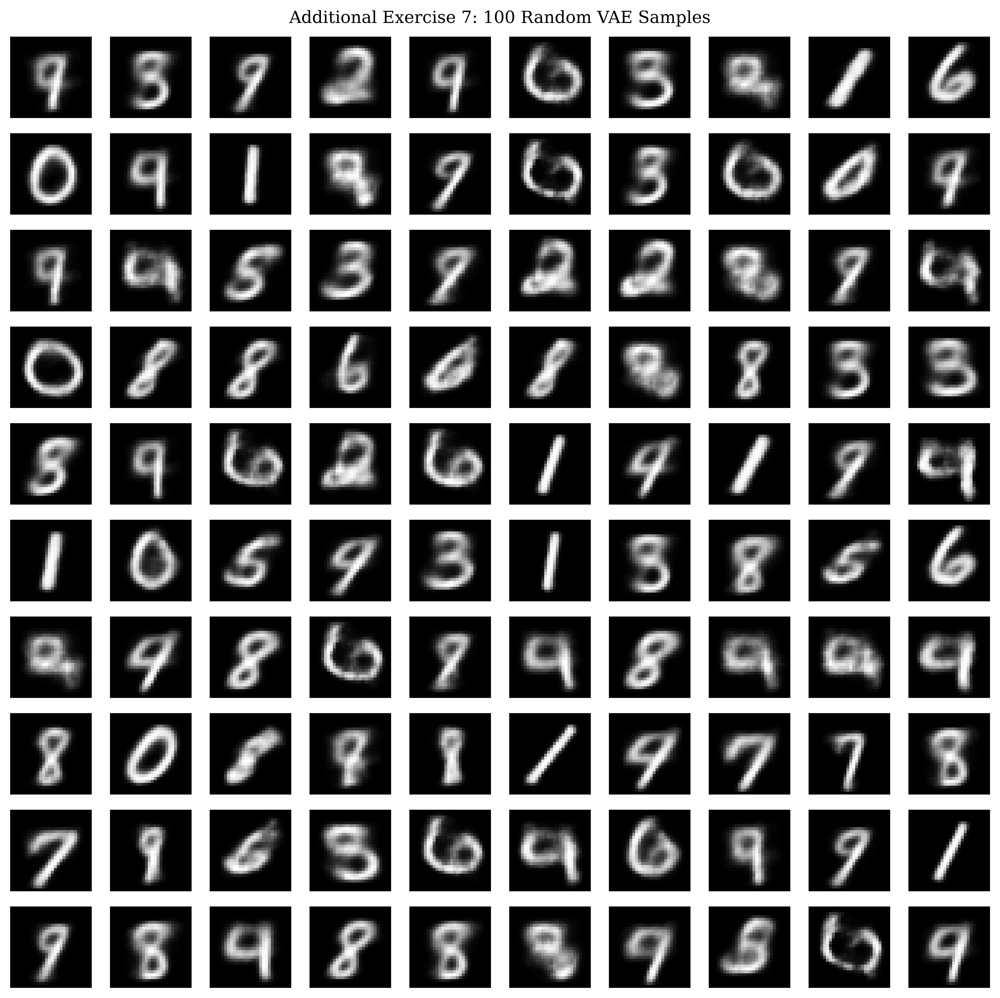

In [41]:
# ============================================================
# Additional Exercise 7
# Generate a larger grid of VAE samples and inspect diversity.
# ============================================================

large_latents = tf.random.normal(shape=(100, 2), seed=700)
large_samples = vae.generate(large_latents).numpy()

fig, axes = plt.subplots(10, 10, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    ax.imshow(large_samples[i].squeeze(), cmap="gray")
    ax.axis("off")
fig.suptitle("Additional Exercise 7: 100 Random VAE Samples")
fig.tight_layout(); save_plot(fig, "19_add_vae_100_samples"); plt.show()


Selected digit-0 test index: 10
Selected digit-1 test index: 178
Saved: /content/lab7_outputs/20_add_digit_region_interpolation.eps




In [42]:
# ============================================================
# Additional Exercise 8
# Select two digit regions in the 2D VAE latent space and interpolate.
# We choose representative points nearest the class centroids for digits 0 and 1.
# ============================================================

z_add = vae.encode_mean(x_add_test).numpy()
centroid_0 = z_add[y_add_test == 0].mean(axis=0)
centroid_1 = z_add[y_add_test == 1].mean(axis=0)
idx0 = np.where(y_add_test == 0)[0][np.argmin(np.linalg.norm(z_add[y_add_test == 0] - centroid_0, axis=1))]
idx1 = np.where(y_add_test == 1)[0][np.argmin(np.linalg.norm(z_add[y_add_test == 1] - centroid_1, axis=1))]

z_a_region = z_add[idx0]
z_b_region = z_add[idx1]
alphas_region = np.linspace(0, 1, 11)
interp_region = np.array([(1-a)*z_a_region + a*z_b_region for a in alphas_region], dtype="float32")
region_images = vae.generate(interp_region).numpy()

print("Selected digit-0 test index:", idx0)
print("Selected digit-1 test index:", idx1)

fig, axes = plt.subplots(1, 11, figsize=(17,2.5))
for i, ax in enumerate(axes):
    ax.imshow(region_images[i].squeeze(), cmap="gray")
    ax.set_title(f"{alphas_region[i]:.1f}")
    ax.axis("off")
fig.suptitle("Additional Exercise 8: Digit-0 to Digit-1 Latent-Region Interpolation")
fig.tight_layout(); save_plot(fig, "20_add_digit_region_interpolation"); plt.show()


In [43]:
# ============================================================
# Save additional-exercise results.
# ============================================================

cae_latent_results.to_csv(os.path.join(PLOT_DIR, "additional_cae_latent_dimensions.csv"), index=False)
noise_type_results.to_csv(os.path.join(PLOT_DIR, "additional_noise_type_comparison.csv"), index=False)
gradient_noise_results.to_csv(os.path.join(PLOT_DIR, "additional_noise_level_ssim.csv"), index=False)
decoder_results.to_csv(os.path.join(PLOT_DIR, "additional_decoder_comparison.csv"), index=False)
vae_latent_results.to_csv(os.path.join(PLOT_DIR, "additional_vae_latent_2_vs_8.csv"), index=False)
beta_results.to_csv(os.path.join(PLOT_DIR, "additional_beta_vae.csv"), index=False)

# Rebuild the archive so it contains both main and additional-exercise outputs.
zip_base = "/content/CS3807_Experiment_7_outputs"
shutil.make_archive(zip_base, "zip", PLOT_DIR)
print(f"Updated archive: {zip_base}.zip")


Updated archive: /content/CS3807_Experiment_7_outputs.zip
